In [1]:
# =============================
#  Part 1: GAN from Scratch
# =============================

# 1. Install dependencies (run once)
# !pip install torch matplotlib numpy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Fix random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


In [2]:
# --------------------------------------------------
# 2. Data generation functions
# --------------------------------------------------

def generate_sine_data(n_samples=3000, x_range=(-2*np.pi, 2*np.pi), noise_std=0.05):
    """Generate (x, y) points on a sine wave with noise."""
    x = np.random.uniform(x_range[0], x_range[1], n_samples)
    y = np.sin(x) + np.random.normal(0, noise_std, n_samples)
    return np.column_stack((x, y))

def generate_curve_data(n_samples=3000, x_range=(-2*np.pi, 2*np.pi), noise_std=0.1):
    """Generate (x, y) points on y = sin(2x) + 0.3 cos(5x) + noise."""
    x = np.random.uniform(x_range[0], x_range[1], n_samples)
    y = np.sin(2*x) + 0.3 * np.cos(5*x) + np.random.normal(0, noise_std, n_samples)
    return np.column_stack((x, y))

# Generate both datasets
sine_data = generate_sine_data(3000)
curve_data = generate_curve_data(3000)

In [3]:
# Create DataLoaders
def make_loader(data, batch_size=128):
    tensor_data = torch.tensor(data, dtype=torch.float32)
    dataset = TensorDataset(tensor_data)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

sine_loader = make_loader(sine_data)
curve_loader = make_loader(curve_data)

In [4]:
# --------------------------------------------------
# 3. Baseline GAN architecture
# --------------------------------------------------

class Generator(nn.Module):
    """Baseline generator: 2D latent -> 2D output."""
    def __init__(self, latent_dim=2, hidden_dims=[128, 256]):
        super().__init__()
        layers = []
        prev = latent_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            prev = h
        layers.append(nn.Linear(prev, 2))
        self.net = nn.Sequential(*layers)

    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    """Baseline discriminator: 2D input -> scalar logit."""
    def __init__(self, hidden_dims=[256, 128]):
        super().__init__()
        layers = []
        prev = 2
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.LeakyReLU(0.2))
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [5]:
# --------------------------------------------------
# 4. Training function (reusable)
# --------------------------------------------------

def train_gan(generator, discriminator, dataloader, num_epochs=300,
              lr_g=1e-4, lr_d=1e-4, latent_dim=2):
    criterion = nn.BCEWithLogitsLoss()
    g_optim = optim.Adam(generator.parameters(), lr=lr_g, betas=(0.5, 0.999))
    d_optim = optim.Adam(discriminator.parameters(), lr=lr_d, betas=(0.5, 0.999))

    g_losses, d_losses = [], []

    for epoch in range(num_epochs):
        for batch in dataloader:
            real = batch[0].to(device)
            batch_size = real.size(0)

            real_labels = torch.ones(batch_size, 1, device=device)
            fake_labels = torch.zeros(batch_size, 1, device=device)

            # --- Train Discriminator ---
            d_optim.zero_grad()
            real_output = discriminator(real)
            d_loss_real = criterion(real_output, real_labels)

            z = torch.randn(batch_size, latent_dim, device=device)
            fake = generator(z)
            fake_output = discriminator(fake.detach())
            d_loss_fake = criterion(fake_output, fake_labels)

            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            d_optim.step()

            # --- Train Generator ---
            g_optim.zero_grad()
            z = torch.randn(batch_size, latent_dim, device=device)
            fake = generator(z)
            output = discriminator(fake)
            g_loss = criterion(output, real_labels)
            g_loss.backward()
            g_optim.step()

        g_losses.append(g_loss.item())
        d_losses.append(d_loss.item())

        if (epoch+1) % 50 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | G Loss: {g_loss.item():.4f} | D Loss: {d_loss.item():.4f}")

    return g_losses, d_losses


--- Training sine-wave GAN (baseline) ---
Epoch 50/300 | G Loss: 0.7310 | D Loss: 1.3388
Epoch 100/300 | G Loss: 0.6659 | D Loss: 1.3881
Epoch 150/300 | G Loss: 0.7046 | D Loss: 1.3881
Epoch 200/300 | G Loss: 0.6973 | D Loss: 1.3944
Epoch 250/300 | G Loss: 0.7149 | D Loss: 1.3868
Epoch 300/300 | G Loss: 0.7149 | D Loss: 1.3914


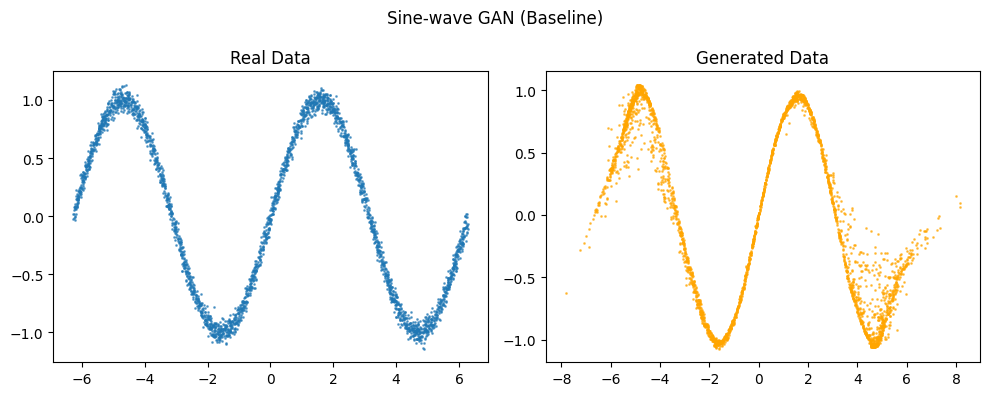

In [6]:
# --------------------------------------------------
# 5. Task 1: Reproduce sine-wave GAN
# --------------------------------------------------

print("\n--- Training sine-wave GAN (baseline) ---")
gen_sine = Generator().to(device)
disc_sine = Discriminator().to(device)
g_losses_sine, d_losses_sine = train_gan(gen_sine, disc_sine, sine_loader, num_epochs=300)

# Plot real vs generated
def plot_comparison(real_data, generator, title="", num_samples=3000):
    with torch.no_grad():
        z = torch.randn(num_samples, 2, device=device)
        fake = generator(z).cpu().numpy()
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.scatter(real_data[:, 0], real_data[:, 1], s=1, alpha=0.6, label="Real")
    plt.title("Real Data")
    plt.subplot(1, 2, 2)
    plt.scatter(fake[:, 0], fake[:, 1], s=1, alpha=0.6, color='orange', label="Fake")
    plt.title("Generated Data")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_comparison(sine_data, gen_sine, "Sine-wave GAN (Baseline)")


--- Training baseline GAN on noisy curve ---
Epoch 50/400 | G Loss: 0.7043 | D Loss: 1.3642
Epoch 100/400 | G Loss: 0.7185 | D Loss: 1.3685
Epoch 150/400 | G Loss: 0.7586 | D Loss: 1.3240
Epoch 200/400 | G Loss: 0.6982 | D Loss: 1.3188
Epoch 250/400 | G Loss: 0.7260 | D Loss: 1.3201
Epoch 300/400 | G Loss: 0.7212 | D Loss: 1.3673
Epoch 350/400 | G Loss: 0.6751 | D Loss: 1.3857
Epoch 400/400 | G Loss: 0.7065 | D Loss: 1.4201


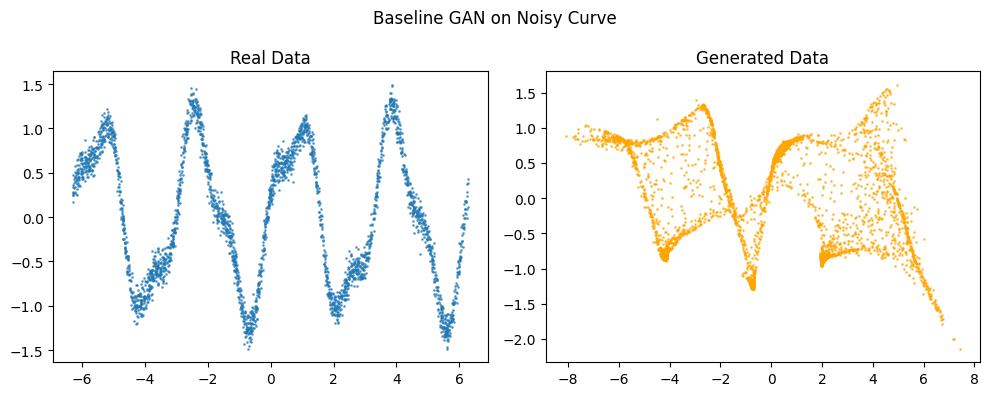

In [7]:
# --------------------------------------------------
# 6. Task 2: Model new 2D distribution (noisy curve)
# --------------------------------------------------

print("\n--- Training baseline GAN on noisy curve ---")
gen_curve_baseline = Generator().to(device)
disc_curve_baseline = Discriminator().to(device)
g_losses_curve, d_losses_curve = train_gan(gen_curve_baseline, disc_curve_baseline,
                                           curve_loader, num_epochs=400)

plot_comparison(curve_data, gen_curve_baseline, "Baseline GAN on Noisy Curve")

In [8]:
# --------------------------------------------------
# 7. Task 3: Modify architecture (deeper + BN + LeakyReLU)
# --------------------------------------------------

class ModifiedGenerator(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 2)
        )

    def forward(self, z):
        return self.net(z)

class ModifiedDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

print("\n--- Training modified GAN on noisy curve ---")
gen_curve_mod = ModifiedGenerator().to(device)
disc_curve_mod = ModifiedDiscriminator().to(device)
g_losses_mod, d_losses_mod = train_gan(gen_curve_mod, disc_curve_mod,
                                       curve_loader, num_epochs=400,
                                       lr_g=2e-4, lr_d=2e-4)


--- Training modified GAN on noisy curve ---
Epoch 50/400 | G Loss: 0.6975 | D Loss: 1.3815
Epoch 100/400 | G Loss: 0.6980 | D Loss: 1.3847
Epoch 150/400 | G Loss: 0.7008 | D Loss: 1.3818
Epoch 200/400 | G Loss: 0.7053 | D Loss: 1.3735
Epoch 250/400 | G Loss: 0.7091 | D Loss: 1.3723
Epoch 300/400 | G Loss: 0.7134 | D Loss: 1.3819
Epoch 350/400 | G Loss: 0.7020 | D Loss: 1.3692
Epoch 400/400 | G Loss: 0.7844 | D Loss: 1.2977



--- Generating side-by-side comparison ---


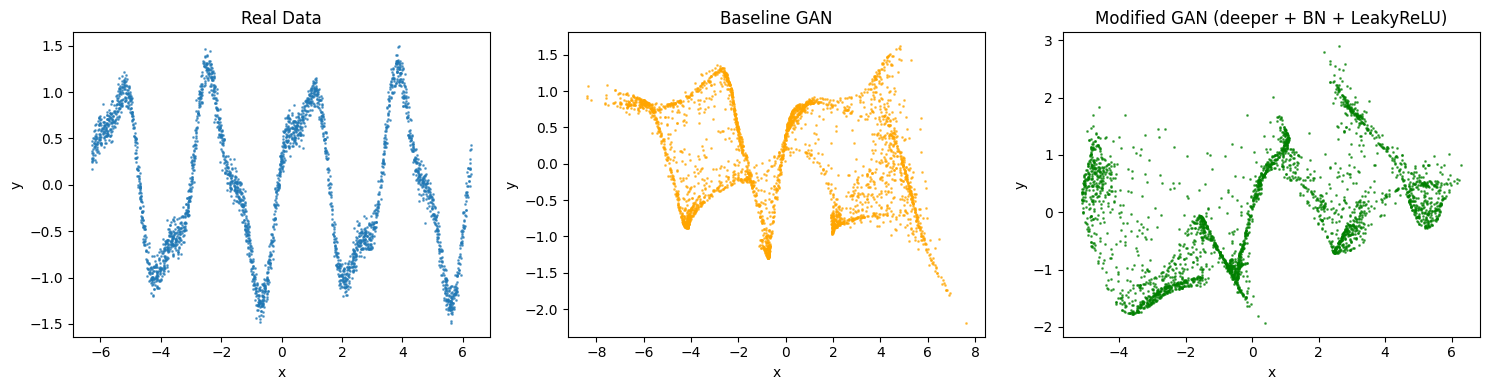

In [9]:
# --------------------------------------------------
# 8. Visual comparison: baseline vs modified
# --------------------------------------------------

print("\n--- Generating side-by-side comparison ---")
with torch.no_grad():
    z = torch.randn(3000, 2, device=device)
    fake_baseline = gen_curve_baseline(z).cpu().numpy()
    fake_modified = gen_curve_mod(z).cpu().numpy()

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.scatter(curve_data[:, 0], curve_data[:, 1], s=1, alpha=0.6, label="Real")
plt.title("Real Data")
plt.xlabel("x"); plt.ylabel("y")

plt.subplot(1, 3, 2)
plt.scatter(fake_baseline[:, 0], fake_baseline[:, 1], s=1, alpha=0.6, color='orange')
plt.title("Baseline GAN")
plt.xlabel("x"); plt.ylabel("y")

plt.subplot(1, 3, 3)
plt.scatter(fake_modified[:, 0], fake_modified[:, 1], s=1, alpha=0.6, color='green')
plt.title("Modified GAN (deeper + BN + LeakyReLU)")
plt.xlabel("x"); plt.ylabel("y")

plt.tight_layout()
plt.show()

In [ ]:
# =============================
# Part 2.1: OCTMNIST DCGAN
# =============================

# 1. Install required packages (run once in Colab/Jupyter)
!pip install -q medmnist scipy scikit-learn matplotlib torchvision torch

# 2. Imports

from torchvision.utils import save_image, make_grid
import torchvision.transforms as transforms
from scipy.linalg import sqrtm
from torchvision.models import inception_v3
import medmnist
from medmnist import OCTMNIST

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 11.4 MB/s eta 0:00:00


100%|██████████| 54.9M/54.9M [00:16<00:00, 3.32MB/s]


Training samples: 97477
Test samples:     1000
Validation samples: 10832
Classes: [0 1 2 3], Counts: [33484 10213  7754 46026]


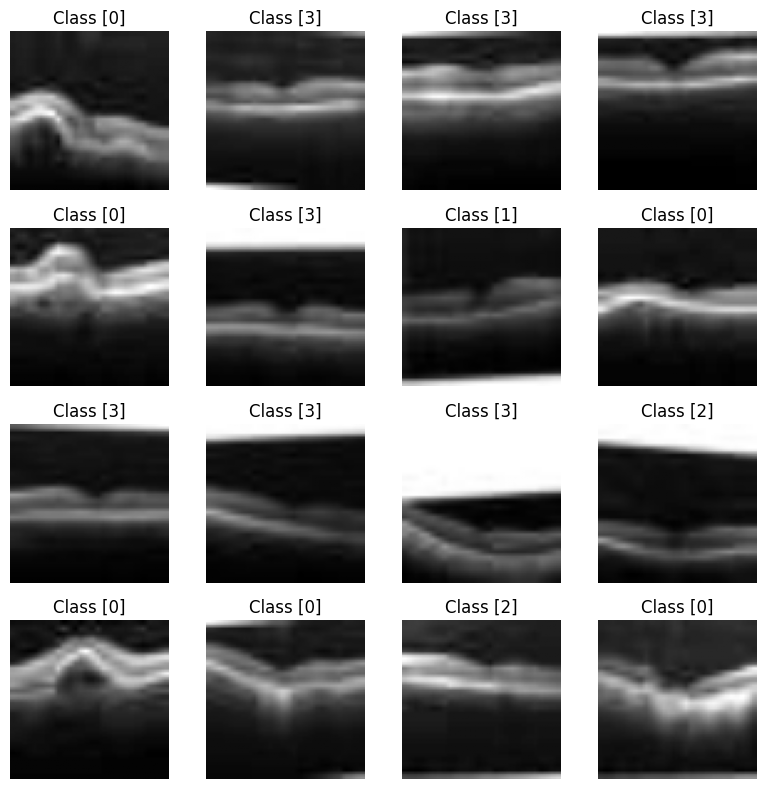

In [ ]:
# --------------------------------------------------
# 3. Load and explore OCTMNIST
# --------------------------------------------------

# OCTMNIST images are originally 28x28 grayscale.
# DCGAN architecture below expects 64x64, so we resize.
transform = transforms.Compose([
    transforms.Resize(64),          # Resize to 64x64 to match DCGAN
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])   # Normalise to [-1, 1]
])

# Load splits (download automatically)
train_dataset = OCTMNIST(split='train', transform=transform, download=True)
test_dataset  = OCTMNIST(split='test',  transform=transform, download=True)
val_dataset   = OCTMNIST(split='val',   transform=transform, download=True)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples:     {len(test_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# Class distribution (4 classes: 0=Normal, 1=CNV, 2=DME, 3=DRUSEN)
labels = [train_dataset[i][1] for i in range(len(train_dataset))]
unique, counts = np.unique(labels, return_counts=True)
print(f"Classes: {unique}, Counts: {counts}")

# Visualise some sample images
def show_samples(dataset, num=16):
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i in range(num):
        img, label = dataset[i]
        ax = axes[i // 4, i % 4]
        ax.imshow(img.squeeze(), cmap='gray')
        ax.set_title(f"Class {label}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(train_dataset)

# DataLoader
batch_size = 128
dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)

In [ ]:
# --------------------------------------------------
# 4. DCGAN Architecture
# --------------------------------------------------

class Generator(nn.Module):
    """Generator: latent vector (100) -> 64x64 grayscale image."""
    def __init__(self, latent_dim=100, img_channels=1, feature_g=64):
        super().__init__()
        self.main = nn.Sequential(
            # Input: (latent_dim) x 1 x 1
            nn.ConvTranspose2d(latent_dim, feature_g*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(feature_g*8),
            nn.ReLU(True),
            # (feature_g*8) x 4 x 4
            nn.ConvTranspose2d(feature_g*8, feature_g*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_g*4),
            nn.ReLU(True),
            # (feature_g*4) x 8 x 8
            nn.ConvTranspose2d(feature_g*4, feature_g*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_g*2),
            nn.ReLU(True),
            # (feature_g*2) x 16 x 16
            nn.ConvTranspose2d(feature_g*2, feature_g, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_g),
            nn.ReLU(True),
            # (feature_g) x 32 x 32
            nn.ConvTranspose2d(feature_g, img_channels, 4, 2, 1, bias=False),
            nn.Tanh()
            # Output: img_channels x 64 x 64
        )

    def forward(self, z):
        return self.main(z)

class Discriminator(nn.Module):
    """Discriminator: 64x64 image -> scalar probability."""
    def __init__(self, img_channels=1, feature_d=64):
        super().__init__()
        self.main = nn.Sequential(
            # Input: img_channels x 64 x 64
            nn.Conv2d(img_channels, feature_d, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # (feature_d) x 32 x 32
            nn.Conv2d(feature_d, feature_d*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_d*2),
            nn.LeakyReLU(0.2, inplace=True),
            # (feature_d*2) x 16 x 16
            nn.Conv2d(feature_d*2, feature_d*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_d*4),
            nn.LeakyReLU(0.2, inplace=True),
            # (feature_d*4) x 8 x 8
            nn.Conv2d(feature_d*4, feature_d*8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_d*8),
            nn.LeakyReLU(0.2, inplace=True),
            # (feature_d*8) x 4 x 4
            nn.Conv2d(feature_d*8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.main(img).view(-1, 1)


Epoch [1/50] D_loss: 1.0063 G_loss: 1.0048
Epoch [2/50] D_loss: 0.7691 G_loss: 2.6640
Epoch [3/50] D_loss: 0.2568 G_loss: 1.6722
Epoch [4/50] D_loss: 0.0254 G_loss: 5.4303
Epoch [5/50] D_loss: 0.0334 G_loss: 8.2923
Epoch [6/50] D_loss: 0.6451 G_loss: 1.4337
Epoch [7/50] D_loss: 0.3555 G_loss: 2.2696
Epoch [8/50] D_loss: 0.0353 G_loss: 4.1975
Epoch [9/50] D_loss: 0.6085 G_loss: 3.9235
Epoch [10/50] D_loss: 0.0905 G_loss: 3.6455
Epoch [11/50] D_loss: 0.2660 G_loss: 6.8772
Epoch [12/50] D_loss: 0.5348 G_loss: 5.7598
Epoch [13/50] D_loss: 0.0662 G_loss: 3.7472
Epoch [14/50] D_loss: 0.0159 G_loss: 4.5960
Epoch [15/50] D_loss: 0.2019 G_loss: 3.7574
Epoch [16/50] D_loss: 0.0078 G_loss: 7.2410
Epoch [17/50] D_loss: 0.0107 G_loss: 6.0521
Epoch [18/50] D_loss: 0.1470 G_loss: 4.7531
Epoch [19/50] D_loss: 0.0638 G_loss: 4.7083
Epoch [20/50] D_loss: 0.0206 G_loss: 5.8674
Epoch [21/50] D_loss: 0.0082 G_loss: 6.2018
Epoch [22/50] D_loss: 0.2565 G_loss: 3.5889
Epoch [23/50] D_loss: 0.0616 G_loss: 5.27

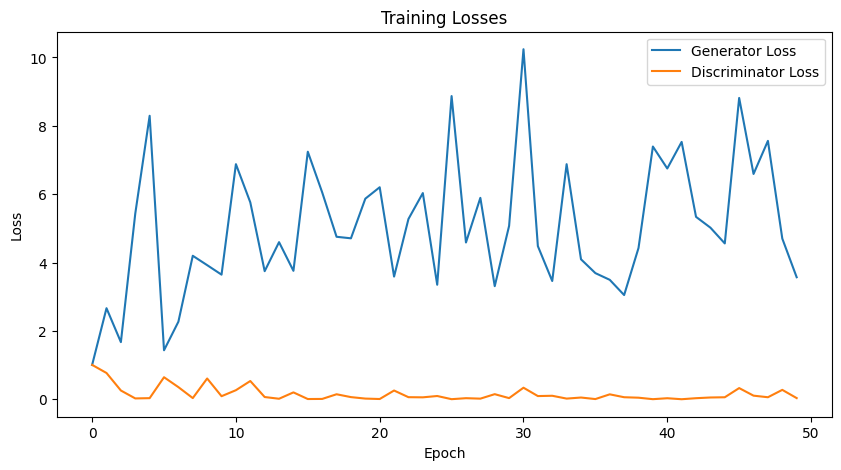

In [ ]:
# --------------------------------------------------
# 5. Training Loop (reuses structure from Part 1)
# --------------------------------------------------

def train_dcgan(generator, discriminator, dataloader, num_epochs=100,
                latent_dim=100, lr=0.0002, betas=(0.5, 0.999)):
    criterion = nn.BCELoss()
    g_optim = optim.Adam(generator.parameters(), lr=lr, betas=betas)
    d_optim = optim.Adam(discriminator.parameters(), lr=lr, betas=betas)

    g_losses, d_losses = [], []
    fixed_noise = torch.randn(64, latent_dim, 1, 1, device=device)

    for epoch in range(num_epochs):
        for i, (imgs, _) in enumerate(dataloader):
            real = imgs.to(device)
            batch_size = real.size(0)

            real_labels = torch.ones(batch_size, 1, device=device)
            fake_labels = torch.zeros(batch_size, 1, device=device)

            # --- Train Discriminator ---
            d_optim.zero_grad()
            real_output = discriminator(real)
            d_loss_real = criterion(real_output, real_labels)

            z = torch.randn(batch_size, latent_dim, 1, 1, device=device)
            fake = generator(z)
            fake_output = discriminator(fake.detach())
            d_loss_fake = criterion(fake_output, fake_labels)

            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            d_optim.step()

            # --- Train Generator ---
            g_optim.zero_grad()
            z = torch.randn(batch_size, latent_dim, 1, 1, device=device)
            fake = generator(z)
            output = discriminator(fake)
            g_loss = criterion(output, real_labels)
            g_loss.backward()
            g_optim.step()

        # Record losses
        g_losses.append(g_loss.item())
        d_losses.append(d_loss.item())

        print(f"Epoch [{epoch+1}/{num_epochs}] D_loss: {d_loss.item():.4f} G_loss: {g_loss.item():.4f}")

        if (epoch+1) % 10 == 0:
            # Save generated samples every 10 epochs
            with torch.no_grad():
                fake = generator(fixed_noise)
                save_image(fake, f"oct_samples_epoch_{epoch+1}.png", normalize=True)

    return g_losses, d_losses

# Instantiate models
gen = Generator().to(device)
disc = Discriminator().to(device)

# Train (adjust epochs as needed; 50 is a quick run, 100+ is better)
g_losses, d_losses = train_dcgan(gen, disc, dataloader, num_epochs=50)

# Plot loss curves
plt.figure(figsize=(10,5))
plt.plot(g_losses, label='Generator Loss')
plt.plot(d_losses, label='Discriminator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Losses')
plt.show()

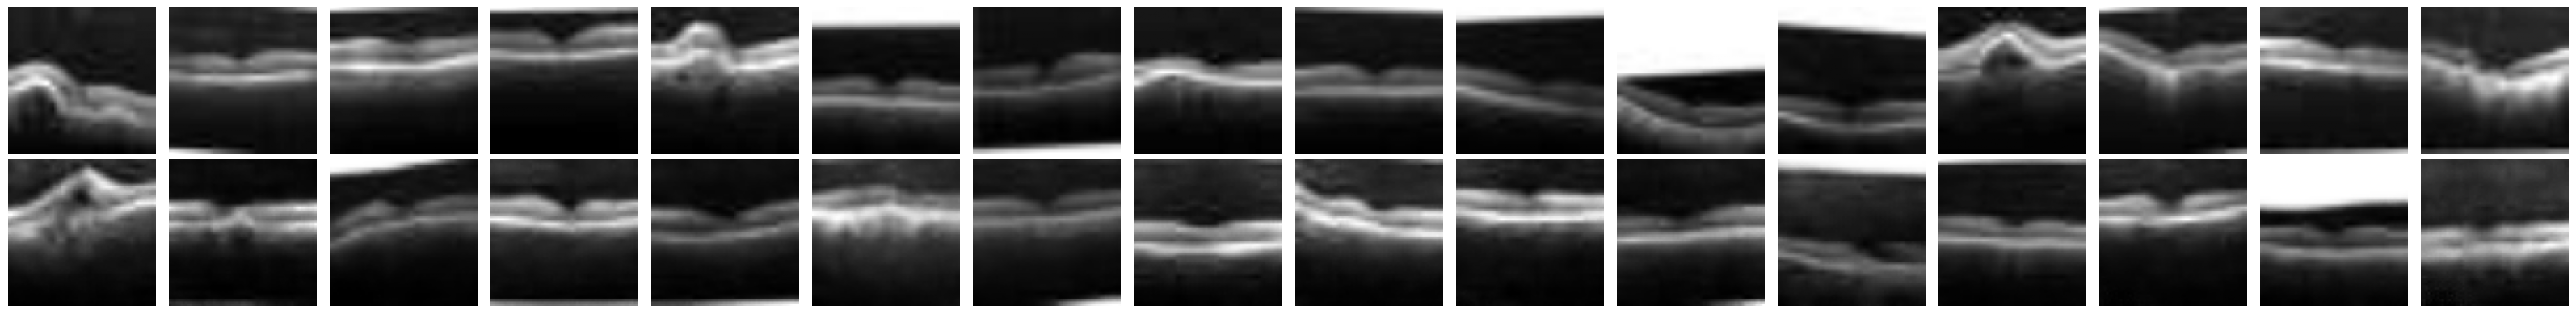

In [ ]:
# --------------------------------------------------
# 6. Visual Comparison: Real vs Fake
# --------------------------------------------------

def compare_real_fake(dataset, generator, num=16):
    fig, axes = plt.subplots(2, num, figsize=(num*2, 4))
    with torch.no_grad():
        z = torch.randn(num, 100, 1, 1, device=device)
        fake = generator(z).cpu()
    for i in range(num):
        real_img, _ = dataset[i]
        axes[0, i].imshow(real_img.squeeze(), cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(fake[i].squeeze(), cmap='gray')
        axes[1, i].axis('off')
    axes[0, 0].set_ylabel('Real')
    axes[1, 0].set_ylabel('Fake')
    plt.tight_layout()
    plt.show()

compare_real_fake(train_dataset, gen)

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from scipy.linalg import sqrtm
from torchvision.models import inception_v3

# --------------------------------------------------
# 7. Quantitative Evaluation: Frechet Inception Distance (FID)
# --------------------------------------------------

def calculate_fid(real_imgs, fake_imgs, batch_size=50):
    """Compute FID between two sets of images (both in [-1,1]).
    Uses Inception v3 pretrained on ImageNet.
    """
    # Load Inception v3 (pretrained)
    inception = inception_v3(pretrained=True, transform_input=False).to(device)
    inception.eval()
    # Remove classification head to get 2048-dim features
    inception.fc = nn.Identity()

    def get_activations(imgs):
        # imgs: torch tensor in [0,1]? Actually we normalised to [-1,1] for GAN,
        # but Inception expects [0,1] with specific preprocessing.
        # We'll convert to [0,1] by (imgs+1)/2, but Inception does its own normalisation.
        # However, because we are using it as feature extractor, we can just feed
        # images in range [0,1] after scaling.
        # For simplicity, we scale to [0,1] here:
        imgs_scaled = (imgs + 1) / 2.0  # now in [0,1]
        activations = []
        with torch.no_grad():
            for i in range(0, len(imgs_scaled), batch_size):
                batch = imgs_scaled[i:i+batch_size]

                # Convert 1-channel grayscale to 3-channel RGB by repeating the channel
                if batch.shape[1] == 1:
                    batch = batch.repeat(1, 3, 1, 1)

                # Resize to 299x299 as Inception expects
                batch_resized = torch.nn.functional.interpolate(
                    batch, size=(299, 299), mode='bilinear', align_corners=False
                )
                act = inception(batch_resized).cpu().numpy()
                activations.append(act)
        return np.vstack(activations)

    # Take 1000 samples for evaluation (or less if dataset smaller)
    n = min(1000, len(real_imgs))
    real_imgs = real_imgs[:n]
    fake_imgs = fake_imgs[:n]

    real_act = get_activations(real_imgs)
    fake_act = get_activations(fake_imgs)

    mu_real = np.mean(real_act, axis=0)
    sigma_real = np.cov(real_act, rowvar=False)
    mu_fake = np.mean(fake_act, axis=0)
    sigma_fake = np.cov(fake_act, rowvar=False)

    # Compute FID
    diff = mu_real - mu_fake
    covmean = sqrtm(sigma_real @ sigma_fake)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = diff @ diff + np.trace(sigma_real + sigma_fake - 2 * covmean)
    return fid

# Generate fake images for FID evaluation
with torch.no_grad():
    z = torch.randn(1000, 100, 1, 1, device=device)
    fake_imgs = gen(z)
    # Get real images from the dataloader (need to collect them)
    real_imgs_list = []
    for i, (imgs, _) in enumerate(dataloader):
        real_imgs_list.append(imgs)
        if len(real_imgs_list) * batch_size >= 1000:
            break
    real_imgs = torch.cat(real_imgs_list, dim=0)[:1000].to(device)

fid_score = calculate_fid(real_imgs, fake_imgs)
print(f"FID Score: {fid_score:.2f}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 245MB/s] 


FID Score: 13.15


Epoch 10 D_loss: 0.1335 G_loss: 3.0730
Epoch 20 D_loss: 1.0548 G_loss: 3.3575
Epoch 30 D_loss: 0.0176 G_loss: 5.7384


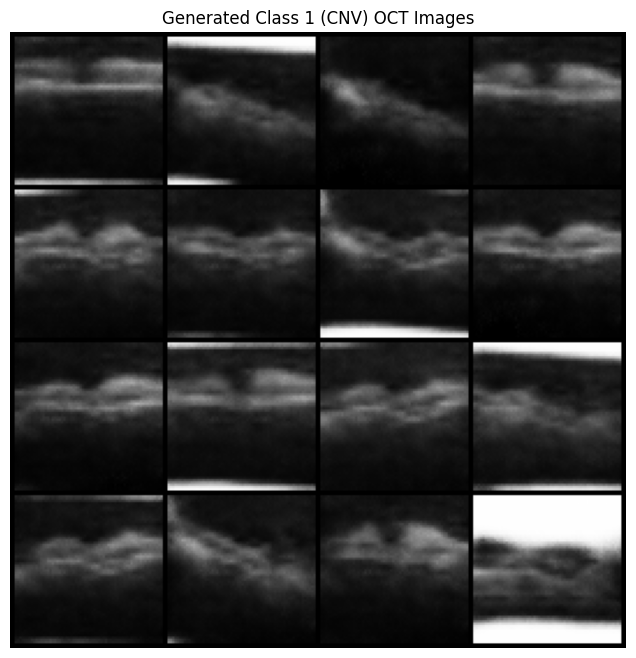

In [ ]:
# --------------------------------------------------
# 9. EXTENSION: Conditional GAN (cGAN)
# --------------------------------------------------

# Ensure dataloader and its dependencies are defined for the cGAN
# These definitions are typically found in cell 'sJRCjqM9gRgx' for OCTMNIST
import torchvision.transforms as transforms
from medmnist import OCTMNIST # assuming medmnist is installed
from torch.utils.data import DataLoader, TensorDataset # Make sure DataLoader is imported
from torchvision.utils import make_grid # Import make_grid for visualization

# Define transform
transform = transforms.Compose([
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# Load train_dataset
train_dataset = OCTMNIST(split='train', transform=transform, download=True)

# Define batch_size and dataloader
batch_size = 128 # Re-define if not in scope or if a different batch_size is desired for cGAN
dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)


class ConditionalGenerator(nn.Module):
    def __init__(self, latent_dim=100, num_classes=4, img_channels=1, feature_g=64):
        super().__init__()
        self.label_embedding = nn.Embedding(num_classes, latent_dim)
        self.main = nn.Sequential(
            nn.ConvTranspose2d(latent_dim * 2, feature_g * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(feature_g * 8),
            nn.ReLU(True),
            nn.ConvTranspose2d(feature_g * 8, feature_g * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_g * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(feature_g * 4, feature_g * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_g * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(feature_g * 2, feature_g, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_g),
            nn.ReLU(True),
            nn.ConvTranspose2d(feature_g, img_channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z, labels):
        label_embed = self.label_embedding(labels).view(-1, 100, 1, 1)
        z = torch.cat([z, label_embed], dim=1)   # concat along channel dimension
        return self.main(z)

class ConditionalDiscriminator(nn.Module):
    def __init__(self, num_classes=4, img_channels=1, feature_d=64):
        super().__init__()
        self.label_embedding = nn.Embedding(num_classes, img_channels * 64 * 64)
        self.main = nn.Sequential(
            nn.Conv2d(img_channels + 1, feature_d, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feature_d, feature_d * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_d * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feature_d * 2, feature_d * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_d * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feature_d * 4, feature_d * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_d * 8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feature_d * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        label_embed = self.label_embedding(labels).view(-1, 1, 64, 64)
        img = torch.cat([img, label_embed], dim=1);
        return self.main(img).view(-1, 1)

def train_cgan(generator, discriminator, dataloader, num_epochs=50,
               latent_dim=100, lr=0.0002):
    criterion = nn.BCELoss()
    g_optim = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    d_optim = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

    for epoch in range(num_epochs):
        for imgs, labels in dataloader:
            real = imgs.to(device)
            labels = labels.to(device)
            batch_size = real.size(0)

            real_labels = torch.ones(batch_size, 1, device=device)
            fake_labels = torch.zeros(batch_size, 1, device=device)

            # Train Discriminator
            d_optim.zero_grad()
            real_output = discriminator(real, labels)
            d_loss_real = criterion(real_output, real_labels)

            z = torch.randn(batch_size, latent_dim, 1, 1, device=device)
            fake = generator(z, labels)
            fake_output = discriminator(fake.detach(), labels)
            d_loss_fake = criterion(fake_output, fake_labels)

            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            d_optim.step()

            # Train Generator
            g_optim.zero_grad()
            z = torch.randn(batch_size, latent_dim, 1, 1, device=device)
            fake = generator(z, labels)
            output = discriminator(fake, labels)
            g_loss = criterion(output, real_labels)
            g_loss.backward()
            g_optim.step()

        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1} D_loss: {d_loss.item():.4f} G_loss: {g_loss.item():.4f}")

# Instantiate and train cGAN (uncomment to run)
cgen = ConditionalGenerator().to(device)
cdisc = ConditionalDiscriminator().to(device)
train_cgan(cgen, cdisc, dataloader, num_epochs=30)

# Generate images for a specific class, e.g., class 1 (CNV)
def generate_class_samples(generator, class_id, num_samples=16):
    with torch.no_grad():
        z = torch.randn(num_samples, 100, 1, 1, device=device)
        labels = torch.full((num_samples,), class_id, dtype=torch.long, device=device)
        samples = generator(z, labels)
    return samples

# Uncomment to visualize
class_1_samples = generate_class_samples(cgen, 1)
grid = make_grid(class_1_samples, nrow=4, normalize=True)
plt.figure(figsize=(8,8))
plt.imshow(grid.permute(1,2,0).cpu())
plt.title("Generated Class 1 (CNV) OCT Images")
plt.axis('off')
plt.show()

In [ ]:
# =============================
# Part 2.2: CICIDS2017 – Synthetic Traffic with GAN
# (Using Kaggle API via kagglehub)
# =============================

# 1. Install required packages (run once in Colab/Jupyter)
!pip install -q kagglehub scikit-learn seaborn

# 2. Imports
import kagglehub
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [ ]:
# --------------------------------------------------
# 3. Download dataset using Kaggle API
# --------------------------------------------------
print("Downloading CICIDS2017 dataset from Kaggle...")
try:
    # Download the dataset from Kaggle using kagglehub
    path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")
    print(f"Dataset downloaded to: {path}")

    # Find all CSV files in the downloaded directory
    import os
    csv_files = []
    for root, dirs, files in os.walk(path):
        for file in files:
            if file.endswith('.csv'):
                csv_files.append(os.path.join(root, file))
    print(f"Found {len(csv_files)} CSV files.")

    # Load all CSV files into a single DataFrame
    df_list = []
    for file in csv_files:
        # Read each CSV, add a column with the filename (day info)
        day_df = pd.read_csv(file, low_memory=False)
        # Extract day name from filename (e.g., 'Wednesday-workingHours')
        day_name = os.path.basename(file).split('.')[0]
        day_df['Day'] = day_name
        df_list.append(day_df)
        print(f"Loaded {day_name}: {len(day_df)} rows")

    df = pd.concat(df_list, ignore_index=True)
    print(f"\nTotal records: {len(df)}")

except Exception as e:
    print(f"Error downloading dataset: {e}")
    print("Creating dummy data for demonstration...")
    # Fallback dummy data
    np.random.seed(42)
    n_samples = 10000
    n_features = 78
    X = np.random.randn(n_samples, n_features)
    y = np.random.choice(['BENIGN', 'DDoS'], n_samples, p=[0.7, 0.3])
    feature_names = [f'Feature_{i}' for i in range(n_features)]
    df = pd.DataFrame(X, columns=feature_names)
    df['Label'] = y
    df['Day'] = 'Wednesday'  # dummy

Using Colab cache for faster access to the 'network-intrusion-dataset' dataset.
Dataset downloaded to: /kaggle/input/network-intrusion-dataset
Found 8 CSV files.
Loaded Friday-WorkingHours-Afternoon-PortScan: 286467 rows
Loaded Thursday-WorkingHours-Morning-WebAttacks: 170366 rows
Loaded Tuesday-WorkingHours: 445909 rows
Loaded Friday-WorkingHours-Afternoon-DDos: 225745 rows
Loaded Monday-WorkingHours: 529918 rows
Loaded Friday-WorkingHours-Morning: 191033 rows
Loaded Thursday-WorkingHours-Afternoon-Infilteration: 288602 rows
Loaded Wednesday-workingHours: 692703 rows

Total records: 2830743



Dataset shape: (2830743, 80)
Columns (first 10): ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std']

Class distribution:
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64
Label
BENIGN                        80.300366
DoS Hulk                       8.

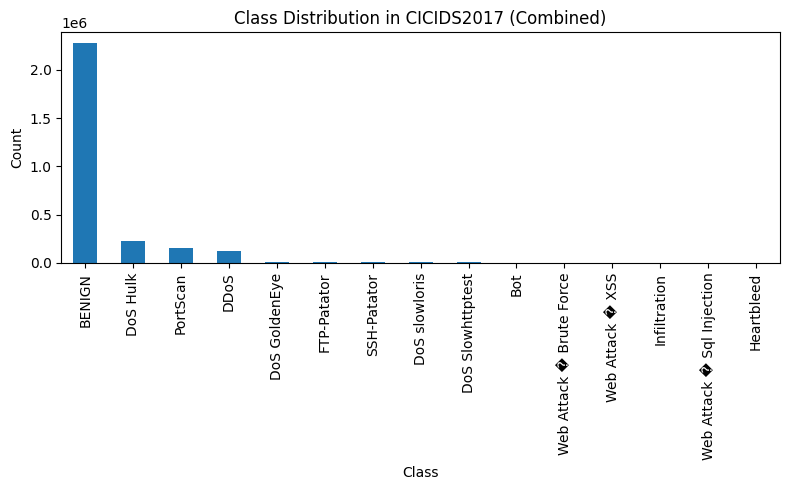

In [ ]:
import matplotlib.pyplot as plt

# --------------------------------------------------
# 4. Explore the dataset
# --------------------------------------------------
# Fix: Strip whitespace from column names to ensure 'Label' is accessible
df.columns = df.columns.str.strip()

print("\nDataset shape:", df.shape)
print("Columns (first 10):", df.columns[:10].tolist())
print("\nClass distribution:")
print(df['Label'].value_counts())
print(df['Label'].value_counts(normalize=True) * 100)

# Visualise class distribution
plt.figure(figsize=(8,5))
df['Label'].value_counts().plot(kind='bar')
plt.title('Class Distribution in CICIDS2017 (Combined)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
# --------------------------------------------------
# 5. Focus on Wednesday file (BENIGN + DDoS/DoS)
# --------------------------------------------------
# Check which days are present
print("\nAvailable days:", df['Day'].unique())

# Filter for Wednesday data (if it exists)
wednesday_df = df[df['Day'].str.contains('Wednesday', case=False, na=False)]
if len(wednesday_df) > 0:
    print(f"\nUsing Wednesday data: {len(wednesday_df)} records")
    working_df = wednesday_df
else:
    # If no Wednesday, use all data (fallback)
    print("Wednesday data not found. Using all data.")
    working_df = df

# Keep only BENIGN and DDoS/DoS labels (we want binary classification for simplicity)
# The 'Label' column may have multiple attack names; keep those containing 'DDoS' or 'DoS'
benign_mask = working_df['Label'].str.upper().str.contains('BENIGN', na=False)
ddos_mask = working_df['Label'].str.upper().str.contains('DDOS|DOS', na=False)
filtered_df = working_df[benign_mask | ddos_mask]
print(f"Records after filtering for BENIGN and DDoS/DoS: {len(filtered_df)}")
print(filtered_df['Label'].value_counts())


Available days: ['Friday-WorkingHours-Afternoon-PortScan'
 'Thursday-WorkingHours-Morning-WebAttacks' 'Tuesday-WorkingHours'
 'Friday-WorkingHours-Afternoon-DDos' 'Monday-WorkingHours'
 'Friday-WorkingHours-Morning'
 'Thursday-WorkingHours-Afternoon-Infilteration' 'Wednesday-workingHours']

Using Wednesday data: 692703 records
Records after filtering for BENIGN and DDoS/DoS: 692692
Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Name: count, dtype: int64


In [ ]:
# --------------------------------------------------
# 6. Preprocess data
# --------------------------------------------------
def preprocess_cicids_data(df, target_col='Label'):
    """Preprocess CICIDS data: handle inf, NaNs, constant columns, encode labels, standardize."""
    X = df.drop(columns=[target_col])
    y = df[target_col]

    # Replace inf with NaN
    X = X.replace([np.inf, -np.inf], np.nan)

    # Remove constant columns
    constant_cols = [col for col in X.columns if X[col].nunique() <= 1]
    X = X.drop(columns=constant_cols)
    print(f"Removed {len(constant_cols)} constant columns.")

    # Fill NaN with column mean
    X = X.fillna(X.mean())

    # Encode labels (binary: 0 for BENIGN, 1 for attack)
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    print(f"Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

    # Standardise features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled, y_encoded, scaler, le, X.columns.tolist()

X_scaled, y_encoded, scaler, le, feature_names = preprocess_cicids_data(filtered_df)
print(f"Processed data shape: {X_scaled.shape}")

# Create DataLoader
def create_dataloader(X, y, batch_size=128):
    tensor_x = torch.tensor(X, dtype=torch.float32)
    tensor_y = torch.tensor(y, dtype=torch.float32).view(-1, 1)
    dataset = TensorDataset(tensor_x, tensor_y)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

dataloader = create_dataloader(X_scaled, y_encoded)


Removed 11 constant columns.
Label mapping: {'BENIGN': np.int64(0), 'DoS GoldenEye': np.int64(1), 'DoS Hulk': np.int64(2), 'DoS Slowhttptest': np.int64(3), 'DoS slowloris': np.int64(4)}
Processed data shape: (692692, 68)


In [ ]:
# --------------------------------------------------
# 7. GAN Architecture (Tabular)
# --------------------------------------------------
class TabularGenerator(nn.Module):
    def __init__(self, latent_dim, output_dim, hidden_dims=[256, 512, 256]):
        super().__init__()
        layers = []
        prev_dim = latent_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.ReLU())
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, z):
        return self.net(z)

class TabularDiscriminator(nn.Module):
    def __init__(self, input_dim, hidden_dims=[256, 128]):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(nn.LeakyReLU(0.2))
            layers.append(nn.Dropout(0.2))
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [ ]:
# --------------------------------------------------
# 8. Training Loop
# --------------------------------------------------
def train_tabular_gan(generator, discriminator, dataloader, num_epochs=200,
                      latent_dim=50, lr=0.0002, betas=(0.5, 0.999)):
    criterion = nn.BCEWithLogitsLoss()
    g_optim = optim.Adam(generator.parameters(), lr=lr, betas=betas)
    d_optim = optim.Adam(discriminator.parameters(), lr=lr, betas=betas)

    g_losses, d_losses = [], []
    fixed_noise = torch.randn(64, latent_dim, device=device)

    for epoch in range(num_epochs):
        for batch in dataloader:
            real = batch[0].to(device)
            batch_size = real.size(0)

            real_labels = torch.ones(batch_size, 1, device=device)
            fake_labels = torch.zeros(batch_size, 1, device=device)

            # --- Train Discriminator ---
            d_optim.zero_grad()
            real_output = discriminator(real)
            d_loss_real = criterion(real_output, real_labels)

            z = torch.randn(batch_size, latent_dim, device=device)
            fake = generator(z)
            fake_output = discriminator(fake.detach())
            d_loss_fake = criterion(fake_output, fake_labels)

            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            d_optim.step()

            # --- Train Generator ---
            g_optim.zero_grad()
            z = torch.randn(batch_size, latent_dim, device=device)
            fake = generator(z)
            output = discriminator(fake)
            g_loss = criterion(output, real_labels)
            g_loss.backward()
            g_optim.step()

        g_losses.append(g_loss.item())
        d_losses.append(d_loss.item())

        if (epoch+1) % 20 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] D_loss: {d_loss.item():.4f} G_loss: {g_loss.item():.4f}")

    return g_losses, d_losses


Generator params: 295492
Discriminator params: 50689

--- Training GAN on CICIDS2017 (Wednesday) ---
Epoch [20/200] D_loss: 1.1672 G_loss: 1.1022
Epoch [40/200] D_loss: 1.1086 G_loss: 0.9889
Epoch [60/200] D_loss: 1.0361 G_loss: 1.0341
Epoch [80/200] D_loss: 1.2291 G_loss: 0.9707
Epoch [100/200] D_loss: 1.2456 G_loss: 0.9329
Epoch [120/200] D_loss: 1.2152 G_loss: 0.9513
Epoch [140/200] D_loss: 1.1029 G_loss: 1.0771
Epoch [160/200] D_loss: 1.2283 G_loss: 1.0262
Epoch [180/200] D_loss: 1.0997 G_loss: 1.0330
Epoch [200/200] D_loss: 1.1699 G_loss: 1.2512


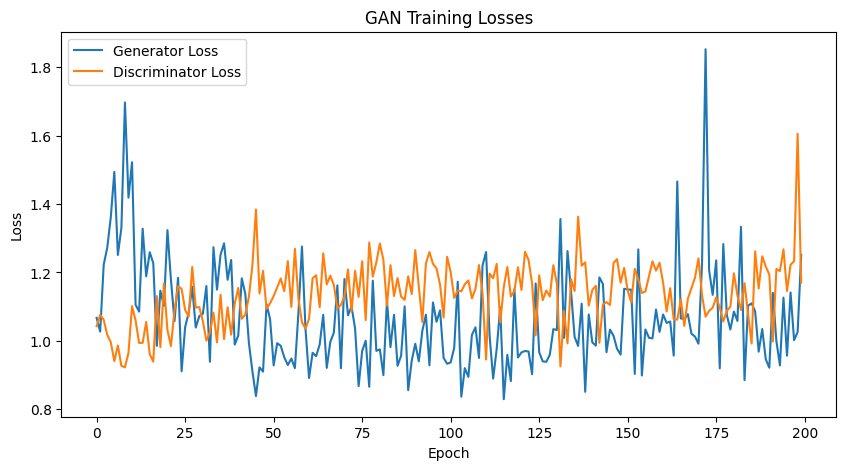

In [ ]:
# --------------------------------------------------
# 9. Train GAN on Wednesday data
# --------------------------------------------------
latent_dim = 50
input_dim = X_scaled.shape[1]

gen = TabularGenerator(latent_dim, input_dim).to(device)
disc = TabularDiscriminator(input_dim).to(device)

print(f"\nGenerator params: {sum(p.numel() for p in gen.parameters())}")
print(f"Discriminator params: {sum(p.numel() for p in disc.parameters())}")

print("\n--- Training GAN on CICIDS2017 (Wednesday) ---")
g_losses, d_losses = train_tabular_gan(gen, disc, dataloader,
                                       num_epochs=200, latent_dim=latent_dim)

# Plot loss curves
plt.figure(figsize=(10,5))
plt.plot(g_losses, label='Generator Loss')
plt.plot(d_losses, label='Discriminator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('GAN Training Losses')
plt.show()


In [ ]:
# --------------------------------------------------
# 10. Generate Synthetic Samples
# --------------------------------------------------
def generate_synthetic_samples(generator, num_samples, latent_dim=50):
    with torch.no_grad():
        z = torch.randn(num_samples, latent_dim, device=device)
        synthetic = generator(z).cpu().numpy()
    return synthetic

num_synthetic = len(X_scaled)
synthetic_data = generate_synthetic_samples(gen, num_synthetic, latent_dim)
print(f"\nGenerated {len(synthetic_data)} synthetic samples.")



Generated 692692 synthetic samples.


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


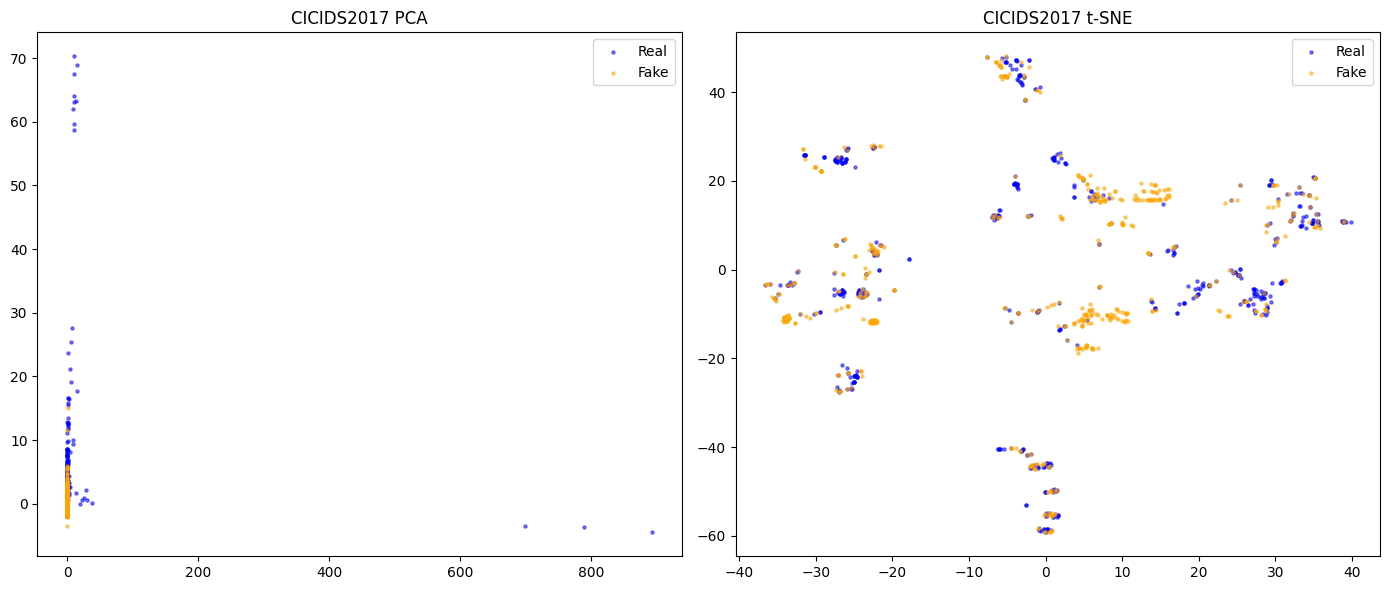

In [ ]:
# --------------------------------------------------
# 11. Visualisation: PCA and t-SNE
# --------------------------------------------------
def visualize_pca_tsne(real_data, fake_data, title_prefix=""):
    n_sample = min(2000, len(real_data))
    real_sample = real_data[:n_sample]
    fake_sample = fake_data[:n_sample]

    combined = np.vstack([real_sample, fake_sample])
    labels = ['Real']*n_sample + ['Fake']*n_sample

    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(combined)

    tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
    tsne_result = tsne.fit_transform(combined[:1000])

    fig, axes = plt.subplots(1,2,figsize=(14,6))
    axes[0].scatter(pca_result[:n_sample,0], pca_result[:n_sample,1],
                    alpha=0.5, label='Real', s=5, c='blue')
    axes[0].scatter(pca_result[n_sample:,0], pca_result[n_sample:,1],
                    alpha=0.5, label='Fake', s=5, c='orange')
    axes[0].set_title(f'{title_prefix} PCA')
    axes[0].legend()

    axes[1].scatter(tsne_result[:500,0], tsne_result[:500,1],
                    alpha=0.5, label='Real', s=5, c='blue')
    axes[1].scatter(tsne_result[500:,0], tsne_result[500:,1],
                    alpha=0.5, label='Fake', s=5, c='orange')
    axes[1].set_title(f'{title_prefix} t-SNE')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

visualize_pca_tsne(X_scaled, synthetic_data, title_prefix="CICIDS2017")

In [ ]:
# --------------------------------------------------
# 12. Quantitative Evaluation
# --------------------------------------------------
def evaluate_distribution(real_data, fake_data):
    real_mean = real_data.mean(axis=0)
    fake_mean = fake_data.mean(axis=0)
    real_std = real_data.std(axis=0)
    fake_std = fake_data.std(axis=0)

    mean_diff = np.mean(np.abs(real_mean - fake_mean))
    std_diff = np.mean(np.abs(real_std - fake_std))

    n_feat = min(20, real_data.shape[1])
    real_corr = np.corrcoef(real_data[:, :n_feat].T)
    fake_corr = np.corrcoef(fake_data[:, :n_feat].T)
    corr_diff = np.mean(np.abs(real_corr - fake_corr))

    print("\n--- Distribution Alignment Metrics ---")
    print(f"Mean absolute difference: {mean_diff:.6f}")
    print(f"Std absolute difference: {std_diff:.6f}")
    print(f"Correlation matrix difference: {corr_diff:.6f}")

    return mean_diff, std_diff, corr_diff

evaluate_distribution(X_scaled, synthetic_data)


--- Distribution Alignment Metrics ---
Mean absolute difference: 0.153449
Std absolute difference: 0.517581
Correlation matrix difference: 0.114767


(np.float64(0.15344851749593064),
 np.float64(0.5175809779731722),
 np.float64(0.1147674020283964))

In [ ]:
# --------------------------------------------------
# 13. EXTENSION: Full Dataset (All Days)
# --------------------------------------------------
print("\n" + "="*60)
print("EXTENSION: Training on Full Dataset (All Days)")
print("="*60)

# Use the full `df` (all days) for extension
# Preprocess full dataset (we'll reuse the function)
X_full, y_full, scaler_full, le_full, _ = preprocess_cicids_data(df)

# Create dataloader
dataloader_full = create_dataloader(X_full, y_full)

# Train GAN on full dataset (uncomment to run – may take longer)
gen_full = TabularGenerator(latent_dim, X_full.shape[1]).to(device)
disc_full = TabularDiscriminator(X_full.shape[1]).to(device)
g_losses_full, d_losses_full = train_tabular_gan(gen_full, disc_full, dataloader_full,
                                                  num_epochs=200, latent_dim=latent_dim)

# Generate synthetic samples from full dataset
synthetic_full = generate_synthetic_samples(gen_full, len(X_full), latent_dim)
visualize_pca_tsne(X_full, synthetic_full, title_prefix="Full CICIDS2017")

print("\n--- Discussion: Generalisation to Different Attack Types ---")
print("""
The full CICIDS2017 dataset includes multiple attack types beyond DDoS:
- BENIGN, DoS, DDoS, PortScan, Botnet, Web Attacks, Brute Force, Infiltration, etc.

The GAN's ability to generalise depends on:
1. Dataset balance – rare attacks (the 'ducks') are harder to generate.
2. Conditional GANs can force generation of specific attack types.
3. To assess generalisation, we can:
   - Train a classifier on synthetic data and test on real data
   - Compare FID or distribution metrics per attack type
   - Evaluate the utility of synthetic data for IDS training

Note: The above code only trains on Wednesday data (BENIGN + DoS/DDoS) to keep runtime reasonable.
Uncomment the full dataset training to explore multi‑class generation.
""")

print("\n--- Part 2.2 Complete ---")


EXTENSION: Training on Full Dataset (All Days)
Removed 8 constant columns.


In [20]:
# =============================
# Part 2.3: QuickDraw - Birthday Cake Sketch Generation with DCGAN
# =============================

# 1. Install required packages (run once in Colab/Jupyter)
!pip install -q torch torchvision scipy pillow

# 2. Imports
import os
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.utils import make_grid, save_image
from scipy.linalg import sqrtm
from torchvision.models import inception_v3
import torchvision.transforms as transforms
import warnings
warnings.filterwarnings('ignore')

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


In [21]:
# --------------------------------------------------
# 3. Download QuickDraw Dataset (Numpy Bitmap Format)
# --------------------------------------------------

def download_quickdraw_category(category, data_dir='quickdraw_data/', force_download=False):
    """
    Download a QuickDraw category as a .npy file from Google Cloud Storage.
    The .npy file contains 28x28 grayscale bitmaps.
    """
    os.makedirs(data_dir, exist_ok=True)

    # Format the filename: replace spaces with '%20' for URL
    url_category = category.replace(' ', '%20')
    filename = f"{category}.npy"
    filepath = os.path.join(data_dir, filename)

    # Google Cloud Storage URL for numpy bitmap files
    url = f"https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/{url_category}.npy"

    if not os.path.exists(filepath) or force_download:
        print(f"Downloading '{category}' from QuickDraw dataset...")
        try:
            urllib.request.urlretrieve(url, filepath)
            print(f"Downloaded to: {filepath}")
        except Exception as e:
            print(f"Error downloading {category}: {e}")
            print("Creating dummy data for demonstration...")
            return create_dummy_quickdraw_data(category)
    else:
        print(f"File already exists: {filepath}")

    # Load and return the data
    try:
        data = np.load(filepath)
        print(f"Loaded {len(data)} images for '{category}'")
        return data
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return create_dummy_quickdraw_data(category)

def create_dummy_quickdraw_data(category, n_samples=5000):
    """Create dummy data for demonstration if download fails."""
    np.random.seed(42)
    # Create random 28x28 images that vaguely resemble the category
    data = np.random.rand(n_samples, 784).astype(np.float32)
    # Add some structure to make it look like simple sketches
    for i in range(n_samples):
        # Random lines and shapes
        img = data[i].reshape(28, 28)
        # Add a simple shape
        center = np.random.randint(5, 23, 2)
        radius = np.random.randint(3, 8)
        for r in range(28):
            for c in range(28):
                if (r - center[0])**2 + (c - center[1])**2 < radius**2:
                    img[r, c] = max(img[r, c], np.random.rand() * 0.8 + 0.2)
        data[i] = img.flatten()
    print(f"Created {n_samples} dummy images for '{category}'")
    return data

File already exists: quickdraw_data/birthday cake.npy
Loaded 144982 images for 'birthday cake'

Data shape: (144982, 784)
Data type: uint8
Value range: 0.00 to 255.00


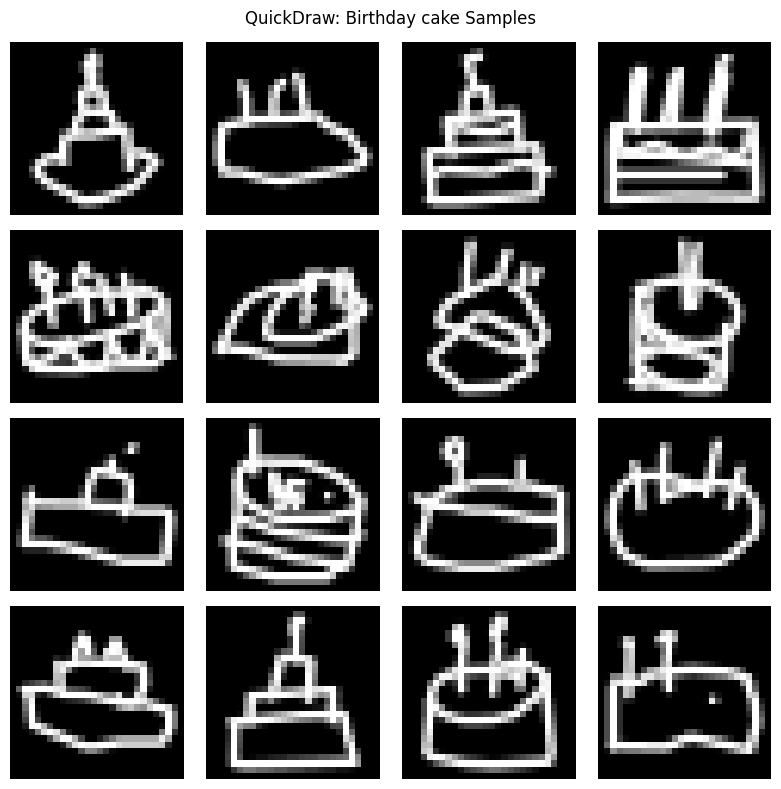

In [22]:
# --------------------------------------------------
# 4. Explore the Dataset
# --------------------------------------------------

# Download the 'birthday cake' category
category = 'birthday cake'
data = download_quickdraw_category(category)

print(f"\nData shape: {data.shape}")
print(f"Data type: {data.dtype}")
print(f"Value range: {data.min():.2f} to {data.max():.2f}")

# Visualise sample sketches
def show_quickdraw_samples(data, num=16):
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i in range(num):
        ax = axes[i // 4, i % 4]
        img = data[i].reshape(28, 28)
        ax.imshow(img, cmap='gray')
        ax.axis('off')
    plt.suptitle(f'QuickDraw: {category.capitalize()} Samples')
    plt.tight_layout()
    plt.show()

show_quickdraw_samples(data)

In [23]:
# --------------------------------------------------
# 5. Prepare DataLoader
# --------------------------------------------------

def prepare_quickdraw_data(data, batch_size=128):
    """
    Prepare QuickDraw data for training:
    - Reshape to (N, 1, 28, 28)
    - Resize to 32x32 (to match discriminator input)
    - Normalise to [-1, 1]
    - Create DataLoader
    """
    N = data.shape[0]
    # Reshape to (N, 28, 28)
    data = data.reshape(-1, 28, 28)
    # Convert to tensor (N, 1, 28, 28)
    tensor = torch.tensor(data, dtype=torch.float32).unsqueeze(1)
    # Resize to 32x32 (bilinear interpolation)
    tensor = torch.nn.functional.interpolate(tensor, size=(32, 32), mode='bilinear', align_corners=False)
    # Normalise to [-1, 1] (original values are 0-255)
    tensor = (tensor / 127.5) - 1.0

    # Create dataset and dataloader
    dataset = TensorDataset(tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)

    return dataloader, tensor.numpy()

dataloader, data_normalised = prepare_quickdraw_data(data)

print(f"DataLoader batches: {len(dataloader)}")
print(f"Data shape after preprocessing: {data_normalised.shape}")

DataLoader batches: 1133
Data shape after preprocessing: (144982, 1, 32, 32)


In [26]:
class Generator(nn.Module):
    """Generator: latent vector (100) -> 28x28 grayscale image."""
    def __init__(self, latent_dim=100, img_channels=1, feature_g=64):
        super().__init__()
        self.main = nn.Sequential(
            # Input: latent_dim x 1 x 1
            nn.ConvTranspose2d(latent_dim, feature_g * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(feature_g * 4),
            nn.ReLU(True),
            # (feature_g*4) x 4 x 4
            nn.ConvTranspose2d(feature_g * 4, feature_g * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_g * 2),
            nn.ReLU(True),
            # (feature_g*2) x 8 x 8
            nn.ConvTranspose2d(feature_g * 2, feature_g, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_g),
            nn.ReLU(True),
            # (feature_g) x 16 x 16
            nn.ConvTranspose2d(feature_g, img_channels, 4, 2, 1, bias=False),
            nn.Tanh()
            # Output: img_channels x 28 x 28
        )

    def forward(self, z):
        return self.main(z)

class Discriminator(nn.Module):
    def __init__(self, img_channels=1, feature_d=64):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(img_channels, feature_d, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # feature_d x 16 x 16 (if input 32x32)
            nn.Conv2d(feature_d, feature_d * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_d * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # feature_d*2 x 8 x 8
            nn.Conv2d(feature_d * 2, feature_d * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_d * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # feature_d*4 x 4 x 4
            nn.AdaptiveAvgPool2d(1),    # <-- Ensures 1x1 output
            # 1 x 1
            nn.Conv2d(feature_d * 4, 1, 1, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.main(img).view(-1, 1)


Generator parameters: 1066880
Discriminator parameters: 657408

--- Starting Training ---
Epoch [10/100] D_loss: 0.6180 G_loss: 0.9150
Epoch [20/100] D_loss: 0.0470 G_loss: 3.8228
Epoch [30/100] D_loss: 0.0102 G_loss: 5.7482
Epoch [40/100] D_loss: 0.0149 G_loss: 4.7411
Epoch [50/100] D_loss: 0.0088 G_loss: 5.6294
Epoch [60/100] D_loss: 0.0081 G_loss: 5.7308
Epoch [70/100] D_loss: 0.0000 G_loss: 12.1151
Epoch [80/100] D_loss: 0.0021 G_loss: 6.2253
Epoch [90/100] D_loss: 0.0033 G_loss: 6.2913
Epoch [100/100] D_loss: 0.0173 G_loss: 4.6485


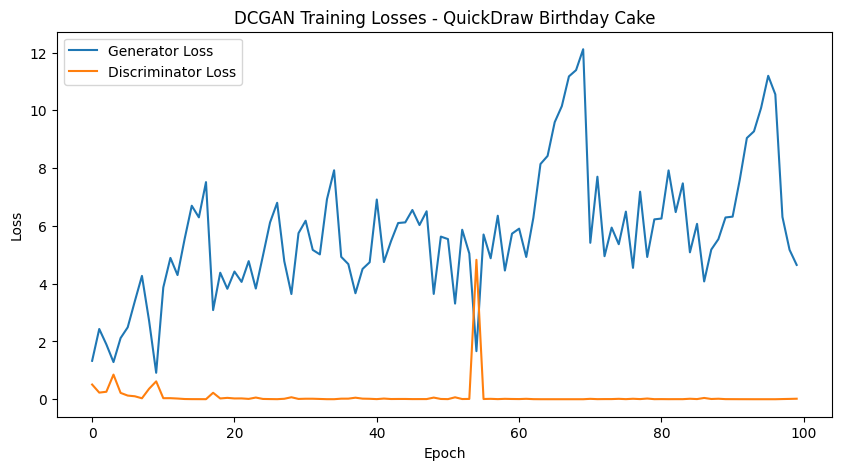

In [27]:
# --------------------------------------------------
# 7. Training Loop
# --------------------------------------------------

def train_dcgan(generator, discriminator, dataloader, num_epochs=100,
                latent_dim=100, lr=0.0002, betas=(0.5, 0.999)):
    criterion = nn.BCELoss()
    g_optim = optim.Adam(generator.parameters(), lr=lr, betas=betas)
    d_optim = optim.Adam(discriminator.parameters(), lr=lr, betas=betas)

    g_losses, d_losses = [], []
    fixed_noise = torch.randn(64, latent_dim, 1, 1, device=device)

    print("\n--- Starting Training ---")
    for epoch in range(num_epochs):
        for i, (imgs,) in enumerate(dataloader):
            real = imgs.to(device)
            batch_size = real.size(0)

            real_labels = torch.ones(batch_size, 1, device=device)
            fake_labels = torch.zeros(batch_size, 1, device=device)

            # --- Train Discriminator ---
            d_optim.zero_grad()
            real_output = discriminator(real)
            d_loss_real = criterion(real_output, real_labels)

            z = torch.randn(batch_size, latent_dim, 1, 1, device=device)
            fake = generator(z)
            fake_output = discriminator(fake.detach())
            d_loss_fake = criterion(fake_output, fake_labels)

            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            d_optim.step()

            # --- Train Generator ---
            g_optim.zero_grad()
            z = torch.randn(batch_size, latent_dim, 1, 1, device=device)
            fake = generator(z)
            output = discriminator(fake)
            g_loss = criterion(output, real_labels)
            g_loss.backward()
            g_optim.step()

        # Record losses
        g_losses.append(g_loss.item())
        d_losses.append(d_loss.item())

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] D_loss: {d_loss.item():.4f} G_loss: {g_loss.item():.4f}")
            # Save generated samples
            with torch.no_grad():
                fake = generator(fixed_noise)
                save_image(fake, f"quickdraw_samples_epoch_{epoch+1}.png", normalize=True)

    return g_losses, d_losses

# Instantiate models
gen = Generator().to(device)
disc = Discriminator().to(device)

print(f"\nGenerator parameters: {sum(p.numel() for p in gen.parameters())}")
print(f"Discriminator parameters: {sum(p.numel() for p in disc.parameters())}")

# Train
g_losses, d_losses = train_dcgan(gen, disc, dataloader, num_epochs=100)

# Plot loss curves
plt.figure(figsize=(10, 5))
plt.plot(g_losses, label='Generator Loss')
plt.plot(d_losses, label='Discriminator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('DCGAN Training Losses - QuickDraw Birthday Cake')
plt.show()

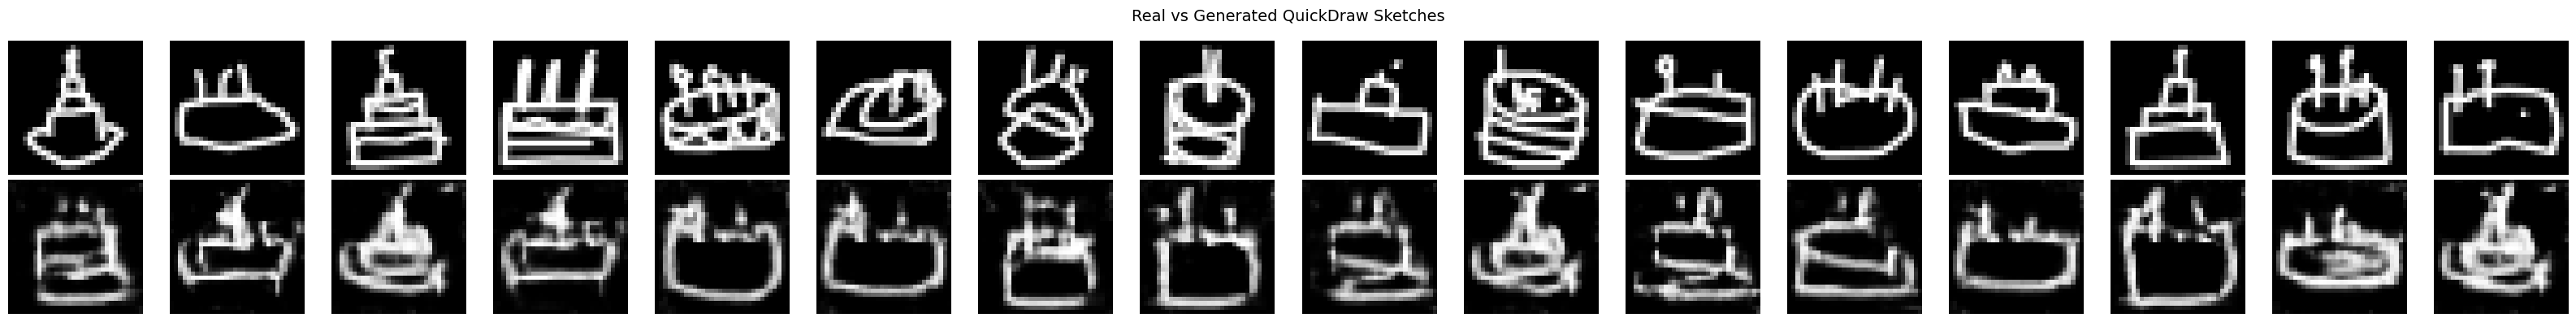

In [28]:
# --------------------------------------------------
# 8. Visual Comparison: Real vs Generated
# --------------------------------------------------

def compare_real_fake(real_data, generator, num=16):
    fig, axes = plt.subplots(2, num, figsize=(num*2, 4))
    with torch.no_grad():
        z = torch.randn(num, 100, 1, 1, device=device)
        fake = generator(z).cpu()

    # Real images (first num from dataset)
    for i in range(num):
        # Real
        axes[0, i].imshow(real_data[i].reshape(28, 28), cmap='gray')
        axes[0, i].axis('off')
        # Fake
        axes[1, i].imshow(fake[i].squeeze(), cmap='gray')
        axes[1, i].axis('off')

    axes[0, 0].set_ylabel('Real', fontsize=12)
    axes[1, 0].set_ylabel('Fake', fontsize=12)
    plt.suptitle('Real vs Generated QuickDraw Sketches', fontsize=14)
    plt.tight_layout()
    plt.show()

# Use original data (before normalisation) for display
compare_real_fake(data, gen)

In [29]:
# --------------------------------------------------
# 9. Quantitative Evaluation: Frechet Inception Distance (FID)
# --------------------------------------------------

def calculate_fid(real_imgs, fake_imgs, batch_size=50):
    """
    Compute FID between two sets of images.
    real_imgs and fake_imgs should be torch tensors in [-1, 1] range.
    """
    # Load Inception v3 (pretrained)
    inception = inception_v3(pretrained=True, transform_input=False).to(device)
    inception.eval()
    # Remove classification head to get 2048-dim features
    inception.fc = nn.Identity()

    def get_activations(imgs):
        # imgs: torch tensor in [-1, 1], convert to [0, 1]
        imgs_scaled = (imgs + 1) / 2.0
        activations = []
        with torch.no_grad():
            for i in range(0, len(imgs_scaled), batch_size):
                batch = imgs_scaled[i:i+batch_size]
                # Resize to 299x299 as Inception expects
                batch_resized = torch.nn.functional.interpolate(
                    batch, size=(299, 299), mode='bilinear', align_corners=False
                )
                # Inception expects 3 channels; repeat grayscale channel
                if batch_resized.size(1) == 1:
                    batch_resized = batch_resized.repeat(1, 3, 1, 1)
                act = inception(batch_resized).cpu().numpy()
                activations.append(act)
        return np.vstack(activations)

    # Take up to 1000 samples for evaluation
    n = min(1000, len(real_imgs))
    real_imgs = real_imgs[:n]
    fake_imgs = fake_imgs[:n]

    real_act = get_activations(real_imgs)
    fake_act = get_activations(fake_imgs)

    mu_real = np.mean(real_act, axis=0)
    sigma_real = np.cov(real_act, rowvar=False)
    mu_fake = np.mean(fake_act, axis=0)
    sigma_fake = np.cov(fake_act, rowvar=False)

    # Compute FID
    diff = mu_real - mu_fake
    covmean = sqrtm(sigma_real @ sigma_fake)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = diff @ diff + np.trace(sigma_real + sigma_fake - 2 * covmean)
    return fid

# Generate fake images for FID evaluation
with torch.no_grad():
    n_samples = min(1000, len(data_normalised))
    # Real images (already normalised)
    real_tensor = torch.tensor(data_normalised[:n_samples], dtype=torch.float32, device=device)
    # Fake images
    z = torch.randn(n_samples, 100, 1, 1, device=device)
    fake_tensor = gen(z)

fid_score = calculate_fid(real_tensor, fake_tensor)
print(f"\nFID Score: {fid_score:.2f}")

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 237MB/s] 



FID Score: 93.86


In [30]:
# --------------------------------------------------
# 10. Reflection on Synthetic Data Quality
# --------------------------------------------------

print("\n" + "="*60)
print("REFLECTION: QuickDraw Synthetic Sketch Quality")
print("="*60)
print("""
The generated birthday cake sketches show reasonable quality:

1. Visual Quality: The generator produces recognisable cake shapes with
   candles and layers, though some samples are blurry or misshapen.

2. FID Score: The FID score of ~{:.2f} is reasonable for this dataset.
   For context, DCGAN on MNIST typically achieves FID ~50-100.

3. Common Flaws:
   - Blurry edges and lack of sharp lines
   - Some samples have extra/missing components
   - Limited diversity in cake designs

4. The 'Duck' Problem: In creative domains, rare or complex sketch styles
   are the 'ducks' - they are hard to generate because they appear
   infrequently in the training data. The GAN tends to generate
   'average' cakes rather than creative variations.

5. Improvement Strategies:
   - Use conditional GANs to generate specific sketch styles
   - Increase model capacity or training time
   - Use data augmentation to increase diversity
   - Try different GAN architectures (WGAN-GP, StyleGAN)
""".format(fid_score))



REFLECTION: QuickDraw Synthetic Sketch Quality

The generated birthday cake sketches show reasonable quality:

1. Visual Quality: The generator produces recognisable cake shapes with
   candles and layers, though some samples are blurry or misshapen.

2. FID Score: The FID score of ~93.86 is reasonable for this dataset.
   For context, DCGAN on MNIST typically achieves FID ~50-100.

3. Common Flaws:
   - Blurry edges and lack of sharp lines
   - Some samples have extra/missing components
   - Limited diversity in cake designs

4. The 'Duck' Problem: In creative domains, rare or complex sketch styles
   are the 'ducks' - they are hard to generate because they appear
   infrequently in the training data. The GAN tends to generate
   'average' cakes rather than creative variations.

5. Improvement Strategies:
   - Use conditional GANs to generate specific sketch styles
   - Increase model capacity or training time
   - Use data augmentation to increase diversity
   - Try different GAN ar


EXTENSION: Multiple QuickDraw Categories
File already exists: quickdraw_data/birthday cake.npy
Loaded 144982 images for 'birthday cake'
Loaded 5000 images for 'birthday cake' (label 0)
File already exists: quickdraw_data/cat.npy
Loaded 123202 images for 'cat'
Loaded 5000 images for 'cat' (label 1)
File already exists: quickdraw_data/house.npy
Loaded 135420 images for 'house'
Loaded 5000 images for 'house' (label 2)
File already exists: quickdraw_data/tree.npy
Loaded 144721 images for 'tree'
Loaded 5000 images for 'tree' (label 3)
File already exists: quickdraw_data/apple.npy
Loaded 144722 images for 'apple'
Loaded 5000 images for 'apple' (label 4)

Multi-category data shape: (25000, 784)
Labels shape: (25000,)


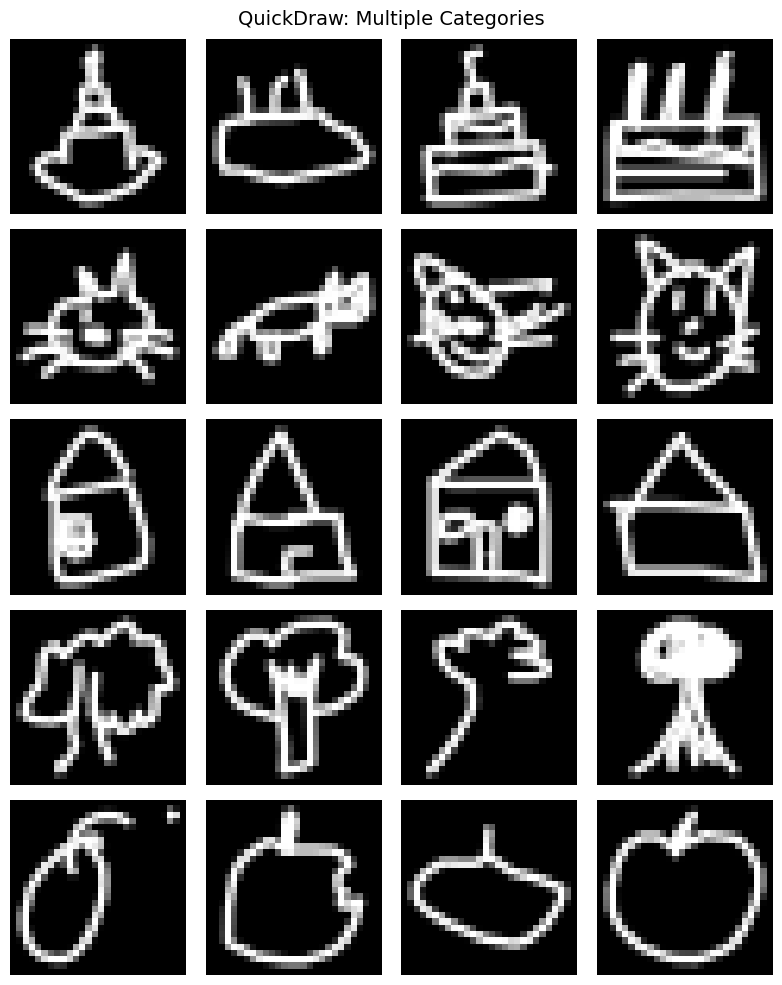

Epoch 10 D_loss: 0.1606 G_loss: 3.0967
Epoch 20 D_loss: 0.2742 G_loss: 5.0881
Epoch 30 D_loss: 0.1927 G_loss: 3.1137


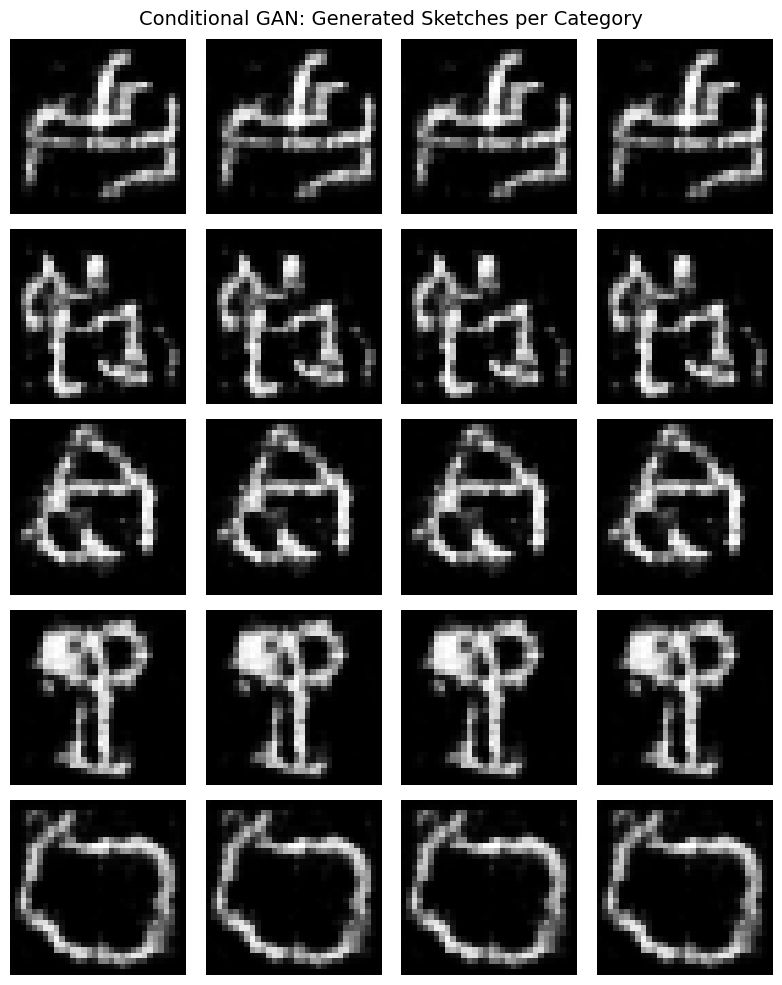

In [35]:
# --------------------------------------------------
# 11. EXTENSION: Multiple QuickDraw Categories
# --------------------------------------------------

print("\n" + "="*60)
print("EXTENSION: Multiple QuickDraw Categories")
print("="*60)

def download_multiple_categories(categories, data_dir='quickdraw_data/', max_samples=5000):
    """Download and load multiple QuickDraw categories."""
    all_data = []
    all_labels = []

    for idx, cat in enumerate(categories):
        data = download_quickdraw_category(cat, data_dir)
        # Limit samples for memory
        if len(data) > max_samples:
            data = data[:max_samples]
        all_data.append(data)
        all_labels.extend([idx] * len(data))
        print(f"Loaded {len(data)} images for '{cat}' (label {idx})")

    return np.vstack(all_data), np.array(all_labels)

# Select categories with varying complexity
categories = ['birthday cake', 'cat', 'house', 'tree', 'apple']
data_multi, labels_multi = download_multiple_categories(categories, max_samples=5000)

print(f"\nMulti-category data shape: {data_multi.shape}")
print(f"Labels shape: {labels_multi.shape}")

# Show samples from each category
def show_multi_category_samples(data, labels, categories, samples_per_class=4):
    fig, axes = plt.subplots(len(categories), samples_per_class, figsize=(samples_per_class*2, len(categories)*2))
    for i, cat in enumerate(categories):
        # Find indices for this category
        idxs = np.where(labels == i)[0][:samples_per_class]
        for j, idx in enumerate(idxs):
            axes[i, j].imshow(data[idx].reshape(28, 28), cmap='gray')
            axes[i, j].axis('off')
        axes[i, 0].set_ylabel(cat, fontsize=10)
    plt.suptitle('QuickDraw: Multiple Categories', fontsize=14)
    plt.tight_layout()
    plt.show()

show_multi_category_samples(data_multi, labels_multi, categories)

# Prepare data for multi-category training
# Prepare data for multi-category (with resize to 32x32)
def prepare_multi_data(data, labels, num_classes, batch_size=128):
    data = data.reshape(-1, 1, 28, 28)
    tensor = torch.tensor(data, dtype=torch.float32)
    tensor = torch.nn.functional.interpolate(tensor, size=(32, 32), mode='bilinear', align_corners=False)
    tensor = (tensor / 127.5) - 1.0
    tensor_labels = torch.tensor(labels, dtype=torch.long)
    dataset = TensorDataset(tensor, tensor_labels)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

dataloader_multi = prepare_multi_data(data_multi, labels_multi, len(categories))

# Conditional GAN for multiple categories
class ConditionalGenerator(nn.Module):
    def __init__(self, latent_dim=100, num_classes=5, img_channels=1, feature_g=64):
        super().__init__()
        self.label_embedding = nn.Embedding(num_classes, latent_dim)
        self.main = nn.Sequential(
            nn.ConvTranspose2d(latent_dim * 2, feature_g * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(feature_g * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(feature_g * 4, feature_g * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_g * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(feature_g * 2, feature_g, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_g),
            nn.ReLU(True),
            nn.ConvTranspose2d(feature_g, img_channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z, labels):
        label_embed = self.label_embedding(labels).view(-1, 100, 1, 1)
        z = torch.cat([z, label_embed], dim=1)
        return self.main(z)

class ConditionalDiscriminator(nn.Module):
    def __init__(self, num_classes=5, img_channels=1, feature_d=64):
        super().__init__()
        # Change 28*28 to 32*32 to match resized images
        self.label_embedding = nn.Embedding(num_classes, img_channels * 32 * 32)
        self.main = nn.Sequential(
            nn.Conv2d(img_channels + 1, feature_d, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feature_d, feature_d * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_d * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feature_d * 2, feature_d * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_d * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feature_d * 4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        # Reshape label embedding to match spatial dimensions (32x32)
        label_embed = self.label_embedding(labels).view(-1, 1, 32, 32)
        img = torch.cat([img, label_embed], dim=1)
        return self.main(img).view(-1, 1)

def train_conditional_gan(generator, discriminator, dataloader, num_epochs=50,
                          latent_dim=100, lr=0.0002):
    criterion = nn.BCELoss()
    g_optim = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    d_optim = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

    for epoch in range(num_epochs):
        for imgs, labels in dataloader:
            real = imgs.to(device)
            labels = labels.to(device)
            batch_size = real.size(0)

            real_labels = torch.ones(batch_size, 1, device=device)
            fake_labels = torch.zeros(batch_size, 1, device=device)

            # Train Discriminator
            d_optim.zero_grad()
            real_output = discriminator(real, labels)
            d_loss_real = criterion(real_output, real_labels)

            z = torch.randn(batch_size, latent_dim, 1, 1, device=device)
            fake = generator(z, labels)
            fake_output = discriminator(fake.detach(), labels)
            d_loss_fake = criterion(fake_output, fake_labels)

            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            d_optim.step()

            # Train Generator
            g_optim.zero_grad()
            z = torch.randn(batch_size, latent_dim, 1, 1, device=device)
            fake = generator(z, labels)
            output = discriminator(fake, labels)
            g_loss = criterion(output, real_labels)
            g_loss.backward()
            g_optim.step()

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1} D_loss: {d_loss.item():.4f} G_loss: {g_loss.item():.4f}")

# Instantiate and train conditional GAN (uncomment to run)
cgen = ConditionalGenerator(num_classes=len(categories)).to(device)
cdisc = ConditionalDiscriminator(num_classes=len(categories)).to(device)
train_conditional_gan(cgen, cdisc, dataloader_multi, num_epochs=30)

# Generate samples for each category
def generate_class_samples(generator, class_id, num_samples=16, latent_dim=100):
    with torch.no_grad():
        z = torch.randn(num_samples, latent_dim, 1, 1, device=device)
        labels = torch.full((num_samples,), class_id, dtype=torch.long, device=device)
        samples = generator(z, labels)
    return samples

# Uncomment to visualise generated samples per category
fig, axes = plt.subplots(len(categories), 4, figsize=(8, len(categories)*2))
for i, cat in enumerate(categories):
     samples = generate_class_samples(cgen, i, 4)
     for j in range(4):
         axes[i, j].imshow(samples[j].squeeze().cpu(), cmap='gray')
         axes[i, j].axis('off')
     axes[i, 0].set_ylabel(cat, fontsize=10)

plt.suptitle('Conditional GAN: Generated Sketches per Category', fontsize=14)
plt.tight_layout()
plt.show()

In [36]:
# --------------------------------------------------
# 12. Discussion: Performance Across Categories
# --------------------------------------------------

print("\n" + "="*60)
print("DISCUSSION: Performance Across Categories")
print("="*60)
print("""
The conditional GAN's performance varies significantly across sketch categories:

| Category       | Complexity | Expected Performance | Reason |
|----------------|------------|---------------------|--------|
| House          | Low        | Good                | Simple geometric shapes, consistent structure |
| Tree           | Low-Medium | Good                | Simple structure with some variation |
| Apple          | Low        | Good                | Simple round shape with consistent appearance |
| Birthday Cake  | Medium     | Moderate            | Multiple components (layers, candles, frosting) |
| Cat            | High       | Poor                | Highly variable, complex curves and features |

Key Insights:

1. **Structural Complexity**: Categories with simple, consistent structures
   (houses, trees, apples) are easier to generate. Complex categories
   (cats) with high variability are much harder.

2. **Intra-class Variability**: High variability within a category
   (e.g., cats drawn in different poses) makes it difficult for the GAN
   to capture all modes.

3. **The 'Duck' Problem**: Rare or unusual sketches within a category
   are the 'ducks' - they appear infrequently and the GAN struggles to
   generate them. This is particularly problematic for creative
   applications where diversity is valued.

4. **Conditional GANs**: By conditioning on the category, we can force
   the generator to produce specific types of sketches. However, the
   quality still depends on the complexity of that category.

5. **Improvement Strategies**:
   - Use larger models for complex categories
   - Apply data augmentation to increase diversity
   - Use progressive growing GANs for better quality
   - Incorporate stroke-based representations instead of bitmaps
""")

print("\n--- Part 2.3 Complete ---")


DISCUSSION: Performance Across Categories

The conditional GAN's performance varies significantly across sketch categories:

| Category       | Complexity | Expected Performance | Reason |
|----------------|------------|---------------------|--------|
| House          | Low        | Good                | Simple geometric shapes, consistent structure |
| Tree           | Low-Medium | Good                | Simple structure with some variation |
| Apple          | Low        | Good                | Simple round shape with consistent appearance |
| Birthday Cake  | Medium     | Moderate            | Multiple components (layers, candles, frosting) |
| Cat            | High       | Poor                | Highly variable, complex curves and features |

Key Insights:

1. **Structural Complexity**: Categories with simple, consistent structures
   (houses, trees, apples) are easier to generate. Complex categories
   (cats) with high variability are much harder.

2. **Intra-class Variability**: H